In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import sys

import pyrootutils

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
os.environ.setdefault("TF_XLA_FLAGS", "--tf_xla_auto_jit=0")
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [3]:
from building.scaling_experiment import (
    ScalingRunConfig,
    load_full_arrays,
    run_experiments,
    summarize_results,
    plot_summary,
)

2026-04-08 14:13:19.382453: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 14:13:19.396565: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 14:13:19.396599: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
COLLECTION = "diff_species"
N_SAMPLES = 20
EPOCHS = 30
PATIENCE = 3
BATCH_SIZE = 32
SEED = 42
THRESHOLD = 0.5
BUILD_MODEL = "cnn2d"
INPUT_REPR = "mel"
MODELS_DIR = ROOT / "models" / "scaling_mel"
RESULTS_FILE = MODELS_DIR / "results.jsonl"

In [5]:
config = ScalingRunConfig(
    collection=COLLECTION,
    build_model=BUILD_MODEL,
    epochs=EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    threshold=THRESHOLD,
    models_dir=MODELS_DIR,
    results_file=RESULTS_FILE,
    input_repr=INPUT_REPR,
)

arrays = load_full_arrays(
    collection=COLLECTION,
    batch_size=BATCH_SIZE,
    seed=SEED,
    input_repr=INPUT_REPR,
)

print(f"Loaded {len(arrays.class_names)} classes:")
print(arrays.class_names)

Found 17499 files belonging to 10 classes.
Found 3749 files belonging to 10 classes.
Found 3751 files belonging to 10 classes.
Loaded 10 classes:
['Phylloscopus_bonelli', 'Phylloscopus_collybita', 'Phylloscopus_fuscatus', 'Phylloscopus_humei', 'Phylloscopus_ibericus', 'Phylloscopus_inornatus', 'Phylloscopus_sibilatrix', 'Phylloscopus_trochiloides', 'Phylloscopus_trochilus', 'Phylloscopus_xanthoschistos']


In [6]:
baseline_rows = run_experiments(arrays, config, run_baseline=True, run_scaling=False)
print(f"New baseline runs: {len(baseline_rows)}")
if baseline_rows:
    print("Last baseline row:")
    print(baseline_rows[-1])

[baseline] target=Phylloscopus_bonelli
[baseline] n_each=1750 n_non_target=1750 n_classes=2
Epoch 1/30


I0000 00:00:1775650422.567866   24254 service.cc:145] XLA service 0x7b1c70005340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775650422.567898   24254 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1775650424.395209   24254 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 - 6s - 51ms/step - accuracy: 0.5014 - loss: 0.7105 - precision: 0.4954 - recall: 0.5029 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 2/30
110/110 - 1s - 6ms/step - accuracy: 0.5020 - loss: 0.6932 - precision: 0.4955 - recall: 0.6169 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/30
110/110 - 1s - 6ms/step - accuracy: 0.4943 - loss: 0.6932 - precision: 0.4904 - recall: 0.5549 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/30
110/110 - 1s - 6ms/step - accuracy: 0.4920 - loss: 0.6932 - precision: 0.4952 - recall: 0.6491 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 0.5000
Epoch 5/30
110/110 - 1s - 6ms/step - accuracy: 0.4943 - loss: 0.6932 - precision: 0.4935 - recall: 0.5883 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 0.5000
[baseline] target=Phylloscopus_collybita
[bas

In [7]:
import pandas as pd

def print_per_class_baseline_results(arrays, results_file):
    try:
        df = pd.read_json(results_file, lines=True)
    except Exception as e:
        print(f"Could not read results file: {e}")
        return

    baseline_df = df[df["run_type"] == "baseline"].copy()
    class_names = list(arrays.class_names)

    # Calculate the longest class name
    max_cls_len = max((len(str(cls)) for cls in class_names), default=0)
    col_width = max(max_cls_len + 2, 15)

    header = f"{'Target Class':<{col_width}} | {'Precision':>9} | {'Recall':>9} | {'Epochs':>6} | {'Timestamp'}"
    print(header)
    print("-" * len(header))

    for cls in class_names:
        cls_str = f"'{cls}'"
        matches = baseline_df[baseline_df["target_class"] == cls]
        
        row = matches.iloc[-1]
        prec = row.get("precision")
        rec = row.get("recall")
        epochs = row.get("epochs_trained")
        timestamp = row.get("timestamp")
        # Print the aligned single row
        print(f"{cls_str:<{col_width}} | {prec:>9.4f} | {rec:>9.4f} | {epochs:>6.0f} | {timestamp!s}")

print_per_class_baseline_results(arrays, RESULTS_FILE)

Target Class                  | Precision |    Recall | Epochs | Timestamp
--------------------------------------------------------------------------
'Phylloscopus_bonelli'        |    0.5000 |    1.0000 |      5 | 2026-04-08 12:13:50.482104+00:00
'Phylloscopus_collybita'      |    0.8870 |    0.8787 |     10 | 2026-04-08 12:14:01.091631+00:00
'Phylloscopus_fuscatus'       |    0.9484 |    0.9481 |     20 | 2026-04-08 12:14:20.019484+00:00
'Phylloscopus_humei'          |    0.8675 |    0.8587 |     27 | 2026-04-08 12:14:42.776563+00:00
'Phylloscopus_ibericus'       |    0.8732 |    0.8707 |      8 | 2026-04-08 12:14:52.491515+00:00
'Phylloscopus_inornatus'      |    0.5000 |    0.5000 |      8 | 2026-04-08 12:15:02.279036+00:00
'Phylloscopus_sibilatrix'     |    0.9304 |    0.9293 |     28 | 2026-04-08 12:15:26.064727+00:00
'Phylloscopus_trochiloides'   |    0.8982 |    0.8973 |     27 | 2026-04-08 12:15:48.653979+00:00
'Phylloscopus_trochilus'      |    0.9289 |    0.9213 |      9 | 2

In [8]:
scaling_rows = run_experiments(
    arrays=arrays,
    config=config,
    n_samples=N_SAMPLES,
    k_values=range(2, len(arrays.class_names)),
    run_baseline=False,
    run_scaling=True,
)
print(f"New scaling runs: {len(scaling_rows)}")
if scaling_rows:
    print("Last scaling row:")
    print(scaling_rows[-1])

[scaling] k=2 sample=1/20


AttributeError: 'list' object has no attribute 'join'

In [ ]:
baseline_metrics, summary_df = summarize_results(RESULTS_FILE)
print(f"Baseline recall: {baseline_metrics.recall:.4f}")
print(f"Baseline precision: {baseline_metrics.precision:.4f}")
summary_df

Baseline recall: 0.9413
Baseline precision: 0.8691


,k,recall_mean,recall_std,precision_mean,precision_std,top1_acc_mean,top1_acc_std
0,2,0.645819,0.287658,0.781951,0.276373,0.759702,0.171276
1,3,0.559079,0.310931,0.674129,0.362447,0.694601,0.236661
2,4,0.461849,0.218292,0.783439,0.175317,0.689837,0.140151
3,5,0.140444,0.000000,0.763018,0.000000,0.456889,0.000000


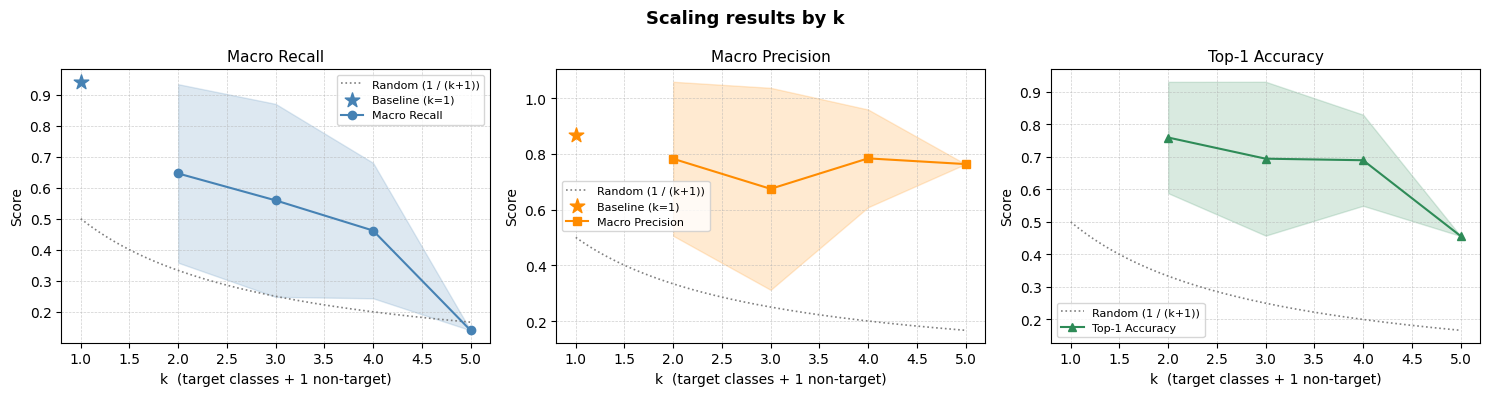

In [ ]:
plot_summary(summary_df, baseline=baseline_metrics)